# Stacking

Stage-2 models trained on the stage-1 outputs from 03 (linear, XGB, LGB, CatBoost). I tried two ideas. First, use the stage-1 OOF as the target, so stage 2 fits the residual of the stage-1 ensemble. Second, use the stage-1 OOF as a feature, appended to the stage-2 training data. I finished with a logistic-regression meta-blender on the OOFs alone.

Everything ran on CPU, scored by AUC. The test set has no labels, so I report CV OOF AUC.

In [1]:
VER = 1

## Load data

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_auc_score

train = pd.read_parquet('data/train_features.parquet')
y_train_true = train['PitNextLap'].astype(int).values
print('Train shape:', train.shape)
train.head(1)

Train shape: (439140, 114)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,...,stintprog_x_ponestop,tyrelife_pct_in_compound,tyrelife_pct_in_stint,tyrelife_pct_in_race_compound,laptime_pct_in_compound,position_pct_in_race,cumdeg_pct_in_stint,raceprogress_decile,tyrelife_decile_in_compound,position_bucket3
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,...,0.335502,0.956276,0.955311,0.955266,0.147495,0.335186,0.8,7,9,1


In [3]:
test = pd.read_parquet('data/test_features.parquet')
print('Test shape:', test.shape)
test.head(1)

Test shape: (188165, 113)


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,...,stintprog_x_ponestop,tyrelife_pct_in_compound,tyrelife_pct_in_stint,tyrelife_pct_in_race_compound,laptime_pct_in_compound,position_pct_in_race,cumdeg_pct_in_stint,raceprogress_decile,tyrelife_decile_in_compound,position_bucket3
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,...,0.191136,0.860569,0.868403,0.759843,0.559999,0.234545,0.65,3,8,0


I load the stage-1 OOF and test-prediction arrays saved by 03. The test preds were stored per fold, shape N_SPLITS by len(test), and I average them over folds here.

In [4]:
oof_linear = np.load(f'data/train_oof_linear_v{VER}.npy')
oof_xgb    = np.load(f'data/train_oof_xgb_v{VER}.npy')
oof_lgb    = np.load(f'data/train_oof_lgb_v{VER}.npy')
oof_cb     = np.load(f'data/train_oof_cb_v{VER}.npy')

pred_linear = np.load(f'data/test_pred_linear_v{VER}.npy').mean(0)
pred_xgb    = np.load(f'data/test_pred_xgb_v{VER}.npy').mean(0)
pred_lgb    = np.load(f'data/test_pred_lgb_v{VER}.npy').mean(0)
pred_cb     = np.load(f'data/test_pred_cb_v{VER}.npy').mean(0)

for name, oof in [('linear', oof_linear), ('xgb', oof_xgb), ('lgb', oof_lgb), ('cb', oof_cb)]:
    print(f'stage-1 {name:7s} OOF AUC = {roc_auc_score(y_train_true, oof):.5f}')

stage-1 linear  OOF AUC = 0.87888


stage-1 xgb     OOF AUC = 0.92424


stage-1 lgb     OOF AUC = 0.93033


stage-1 cb      OOF AUC = 0.93186


## Cross-validation setup

Stage 2 reuses the same 10-fold StratifiedGroupKFold grouped by Race and Year, so the validation folds line up with the stage-1 OOF folds. I stack on the static engineered features only, no per-fold target encodings. That signal is already baked into the stage-1 OOFs.

In [5]:
N_SPLITS = 10
RANDOM_STATE = 42
TARGET = 'PitNextLap'

groups = train.groupby(['Race', 'Year']).ngroup().values
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Static features (everything 03_Baselines used EXCEPT the per-fold target encodings).
RAW_NUMERIC = ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position',
               'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
               'RaceProgress', 'Position_Change']
ENGINEERED  = ['stint_progress', 'laps_remaining_frac', 'p_one_stop',
               'pit_window_cdf', 'compound_stint_pit_rate', 'prev_lap_time_delta',
               'laptime_tenths', 'laptime_hundredths', 'laptime_thousandths',
               'tyrelife_is_integer', 'nearest_real_pitnextlap', 'nearest_real_distance',
               'lap_time_pct_in_lap', 'same_compound_drivers_this_lap']
STATIC = RAW_NUMERIC + ENGINEERED + ['Race']
print(f'static features for stacking: {len(STATIC)}')

static features for stacking: 26


## Stacking, OOF as target (residual)

The stage-1 ensemble is the mean of the four OOFs. I trained an XGBoost regressor to predict the residual, y minus base, then added the base prediction back. The model learns what the ensemble still gets wrong. Final values can fall slightly outside 0 to 1, which is fine. AUC only cares about ranking.

In [6]:
from xgboost import XGBRegressor

# Stage-1 ensemble = mean of the four base OOFs / test preds
base_oof  = np.column_stack([oof_linear, oof_xgb, oof_lgb, oof_cb]).mean(1)
base_pred = np.column_stack([pred_linear, pred_xgb, pred_lgb, pred_cb]).mean(1)
print(f'base (mean of 4) OOF AUC = {roc_auc_score(y_train_true, base_oof):.5f}')

xgb_params = dict(
    n_estimators=2000, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, objective='reg:squarederror',
    tree_method='hist', enable_categorical=True,
    random_state=RANDOM_STATE, early_stopping_rounds=50,
)

X      = train[STATIC].copy()
X_test = test[STATIC].copy()
X['Race']      = X['Race'].astype('category')
X_test['Race'] = pd.Categorical(X_test['Race'], categories=X['Race'].cat.categories)
y = y_train_true - base_oof   # continuous residual target

oof_stack  = np.zeros(len(train))
pred_stack = np.zeros((N_SPLITS, len(test)))

for fold, (tr, va) in enumerate(cv.split(X, y_train_true, groups)):
    model = XGBRegressor(**xgb_params)
    model.fit(X.iloc[tr], y[tr], eval_set=[(X.iloc[va], y[va])], verbose=500)
    oof_stack[va]    = model.predict(X.iloc[va])
    pred_stack[fold] = model.predict(X_test)
    fold_auc = roc_auc_score(y_train_true[va], base_oof[va] + oof_stack[va])
    print(f'Fold {fold+1} AUC: {fold_auc:.5f}  best_iter={model.best_iteration}')

# Add the base prediction back
oof_stack  += base_oof
pred_stack += base_pred

print('-' * 40)
print(f'Residual-stack, CV OOF AUC: {roc_auc_score(y_train_true, oof_stack):.5f}')

base (mean of 4) OOF AUC = 0.92626


[0]	validation_0-rmse:0.26919


[50]	validation_0-rmse:0.27791


Fold 1 AUC: 0.94407  best_iter=0


[0]	validation_0-rmse:0.29684


...

Fold 9 AUC: 0.92539  best_iter=0


[0]	validation_0-rmse:0.27134


[50]	validation_0-rmse:0.27334


Fold 10 AUC: 0.94561  best_iter=0
----------------------------------------


Residual-stack, CV OOF AUC: 0.92602


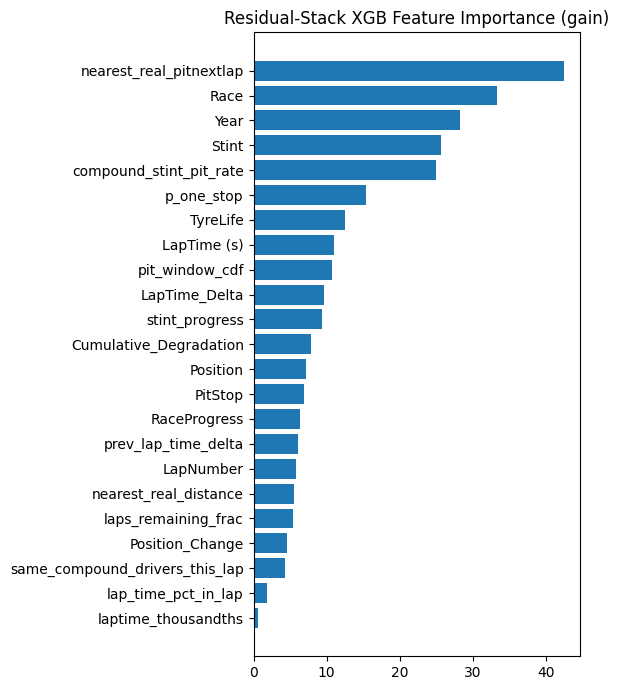

In [7]:
# XGB importance (gain). Keys are column names since we pass a DataFrame.
score = model.get_booster().get_score(importance_type='gain')
imp = pd.DataFrame({'feature': list(score.keys()), 'importance': list(score.values())})\
        .sort_values('importance', ascending=False)
plt.figure(figsize=(6, 7))
plt.barh(imp['feature'], imp['importance'])
plt.gca().invert_yaxis()
plt.title('Residual-Stack XGB Feature Importance (gain)')
plt.tight_layout()
plt.show()

In [8]:
np.save(f'data/train_oof_stack_target_v{VER}.npy', oof_stack)
np.save(f'data/test_pred_stack_target_v{VER}.npy', pred_stack)

## Stacking, OOF as feature

Here I append the four stage-1 OOFs as feature columns and train an XGBoost classifier on the static features plus the OOFs. The importance plot should show the OOF columns dominating. The model leans on the stage-1 predictions and uses the raw features to adjust at the margins.

In [9]:
from xgboost import XGBClassifier

OOF_COLS = ['oof_linear', 'oof_xgb', 'oof_lgb', 'oof_cb']
Xf      = train[STATIC].copy()
Xf_test = test[STATIC].copy()
Xf['Race']      = Xf['Race'].astype('category')
Xf_test['Race'] = pd.Categorical(Xf_test['Race'], categories=Xf['Race'].cat.categories)
for col, oof, pred in zip(OOF_COLS, [oof_linear, oof_xgb, oof_lgb, oof_cb],
                          [pred_linear, pred_xgb, pred_lgb, pred_cb]):
    Xf[col]      = oof
    Xf_test[col] = pred

clf_params = dict(
    n_estimators=2000, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, objective='binary:logistic',
    tree_method='hist', enable_categorical=True, eval_metric='auc',
    random_state=RANDOM_STATE, early_stopping_rounds=50, verbosity=0,
)

oof_stack2  = np.zeros(len(train))
pred_stack2 = np.zeros((N_SPLITS, len(test)))

for fold, (tr, va) in enumerate(cv.split(Xf, y_train_true, groups)):
    model = XGBClassifier(**clf_params)
    model.fit(Xf.iloc[tr], y_train_true[tr], eval_set=[(Xf.iloc[va], y_train_true[va])], verbose=500)
    oof_stack2[va]    = model.predict_proba(Xf.iloc[va])[:, 1]
    pred_stack2[fold] = model.predict_proba(Xf_test)[:, 1]
    print(f'Fold {fold+1} AUC: {roc_auc_score(y_train_true[va], oof_stack2[va]):.5f}  best_iter={model.best_iteration}')

print('-' * 40)
print(f'Feature-stack, CV OOF AUC: {roc_auc_score(y_train_true, oof_stack2):.5f}')

[0]	validation_0-auc:0.93333


[72]	validation_0-auc:0.93797


Fold 1 AUC: 0.93805  best_iter=22


[0]	validation_0-auc:0.91888


[118]	validation_0-auc:0.92243


...

Fold 9 AUC: 0.92892  best_iter=6


[0]	validation_0-auc:0.94571


[81]	validation_0-auc:0.94710


Fold 10 AUC: 0.94750  best_iter=31
----------------------------------------


Feature-stack, CV OOF AUC: 0.90991


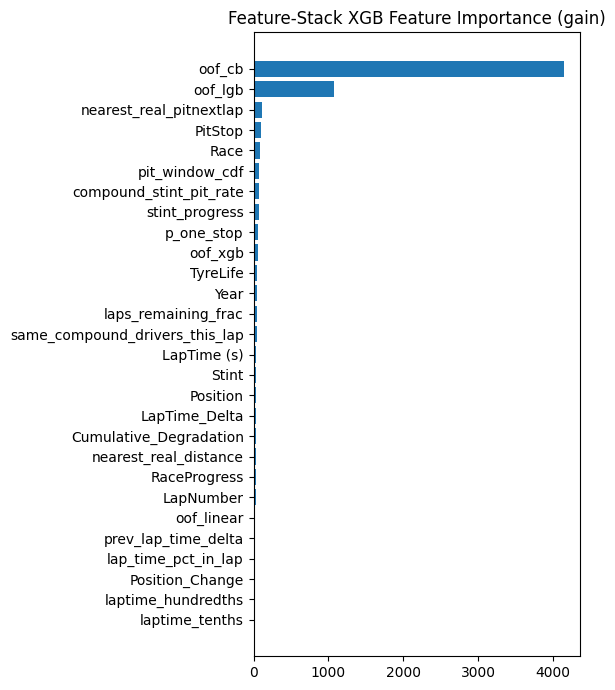

In [10]:
score = model.get_booster().get_score(importance_type='gain')
imp = pd.DataFrame({'feature': list(score.keys()), 'importance': list(score.values())})\
        .sort_values('importance', ascending=False)
plt.figure(figsize=(6, 7))
plt.barh(imp['feature'], imp['importance'])
plt.gca().invert_yaxis()
plt.title('Feature-Stack XGB Feature Importance (gain)')
plt.tight_layout()
plt.show()

In [11]:
np.save(f'data/train_oof_stack_feature_v{VER}.npy', oof_stack2)
np.save(f'data/test_pred_stack_feature_v{VER}.npy', pred_stack2)

## Meta-blender and comparison

Last, a logistic-regression meta-learner on the four stage-1 OOFs alone. That is the standard level-2 blender. Honest OOF comes from cross_val_predict. I compare every approach by CV OOF AUC. A later notebook writes the final submission.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

X_meta      = np.column_stack([oof_linear, oof_xgb, oof_lgb, oof_cb])
X_meta_test = np.column_stack([pred_linear, pred_xgb, pred_lgb, pred_cb])

meta = LogisticRegression(C=1.0, max_iter=2000)
meta_oof = cross_val_predict(meta, X_meta, y_train_true, cv=5, method='predict_proba', n_jobs=-1)[:, 1]
meta.fit(X_meta, y_train_true)
meta_pred = meta.predict_proba(X_meta_test)[:, 1]
print('meta coefficients:', dict(zip(['linear', 'xgb', 'lgb', 'cb'], np.round(meta.coef_[0], 3))))

np.save(f'data/train_oof_stack_meta_v{VER}.npy', meta_oof)
np.save(f'data/test_pred_stack_meta_v{VER}.npy', meta_pred[None, :])

meta coefficients: {'linear': np.float64(-0.639), 'xgb': np.float64(-1.371), 'lgb': np.float64(3.194), 'cb': np.float64(5.433)}


In [13]:
# Compare every candidate by CV OOF AUC.
candidates = {
    'mean_blend':     base_oof,
    'residual_stack': oof_stack,
    'feature_stack':  oof_stack2,
    'meta_blend':     meta_oof,
}
scores = {k: roc_auc_score(y_train_true, v) for k, v in candidates.items()}
summary = pd.DataFrame({'OOF AUC': scores}).sort_values('OOF AUC', ascending=False)
print(summary.to_string())

                 OOF AUC
meta_blend      0.932493
mean_blend      0.926259
residual_stack  0.926024
feature_stack   0.909907
